In [1]:
# analysis showing state-dependent value decoding
# Created on March 1, 2026
# by Thomas Elston

In [2]:
# imports 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
import glob
import os
import h5_utilities_module as h5u
warnings.filterwarnings("ignore", message="Mean of empty slice", category=RuntimeWarning)

In [3]:
#functions
def calculate_mean_and_interval(data, type='sem', num_samples=1000, alpha=0.05):
    """
    Calculate mean and either SEM or bootstrapped CI for each column of the input array, disregarding NaN values.

    Parameters:
    - data: 2D numpy array
    - type: str, either 'sem' or 'bootstrap_ci'
    - num_samples: int, number of bootstrap samples (applicable only for type='bootstrap_ci')
    - alpha: float, significance level for the confidence interval (applicable only for type='bootstrap_ci')

    Returns:
    - means: 1D numpy array containing means for each column
    - interval: 1D numpy array containing SEMs or bootstrapped CIs for each column
    """
    nan_mask = ~np.isnan(data)
    
    nanmean_result = np.nanmean(data, axis=0)
    n_valid_values = np.sum(nan_mask, axis=0)
    
    if type == 'sem':
        nanstd_result = np.nanstd(data, axis=0)
        interval = nanstd_result / np.sqrt(n_valid_values)
        
    elif type == 'percentile':
        interval = np.mean(np.array([np.abs(nanmean_result - np.nanpercentile (data, 5, axis=0)), np.abs(nanmean_result - np.nanpercentile (data, 95, axis=0))]))
        
        
    elif type == 'bootstrap':
        n_rows, n_cols = data.shape

        # Initialize array to store bootstrap means
        bootstrap_means = np.zeros((num_samples, n_cols))

        # Perform bootstrap resampling for each column
        for col in range(n_cols):
            
            if np.sum(nan_mask[:, col]) > 0:
                bootstrap_samples = np.random.choice(data[:, col][nan_mask[:, col]], size=(num_samples, n_rows), replace=True)
                bootstrap_means[:, col] = np.nanmean(bootstrap_samples, axis=1)
            else:
                bootstrap_means[:, col] = np.nan

        # Calculate confidence interval bounds
        ci_lower = np.percentile(bootstrap_means, 100 * (alpha / 2), axis=0)
        ci_upper = np.percentile(bootstrap_means, 100 * (1 - alpha / 2), axis=0)
        
        interval = np.nanmean([abs(bootstrap_means - ci_lower), abs(bootstrap_means - ci_upper)], axis=0)
        
        interval = np.nanmean(interval, axis=0)

    else:
        raise ValueError("Invalid 'type' argument. Use either 'sem' or 'bootstrap'.")
    
    return nanmean_result, interval


def get_ch_and_unch_vals(bhv):
    """
    Extracts chosen (ch_val) and unchosen (unch_val) values associated with each trial.

    Parameters:
    - bhv (DataFrame): DataFrame behavioral data.

    Returns:
    - ch_val (ndarray): Array of chosen values for each trial.
    - unch_val (ndarray): Array of unchosen values for each trial. 
                          - places 0s for unchosen values on forced choice trials
    """
    ch_val = np.zeros(shape=(len(bhv, )))
    unch_val = np.zeros(shape=(len(bhv, )))

    bhv['r_val'] = bhv['r_val'].fillna(0)
    bhv['l_val'] = bhv['l_val'].fillna(0)

    ch_left = bhv['side'] == -1
    ch_right = bhv['side'] == 1

    ch_val[ch_left] = bhv['l_val'].loc[ch_left].astype(int)
    ch_val[ch_right] = bhv['r_val'].loc[ch_right].astype(int)

    unch_val[ch_left] = bhv['r_val'].loc[ch_left].astype(int)
    unch_val[ch_right] = bhv['l_val'].loc[ch_right].astype(int)

    return ch_val, unch_val

In [4]:
# where are the data?
data_dir = r'C:\Users\thome\Documents\PYTHON\OFC-CdN 3 state self control\decoder_output/'

# get their relevant paths
data_files = h5u.find_h5_files(data_dir)

In [5]:
h5u.list_hdf5_data(data_files[0])

Datasets in 'C:\Users\thome\Documents\PYTHON\OFC-CdN 3 state self control\decoder_output\D20231219_Rec05_decoder.h5':
CdN_acc_mean
CdN_all_dir_pp
CdN_alt_ch
CdN_alt_unch
CdN_ch
CdN_ch_dir_pp
CdN_dir_acc
CdN_pp
CdN_unch
CdN_unch_dir_pp
OFC_acc_mean
OFC_all_dir_pp
OFC_alt_ch
OFC_alt_unch
OFC_ch
OFC_ch_dir_pp
OFC_dir_acc
OFC_pp
OFC_unch
OFC_unch_dir_pp
bhv
ts


In [6]:
# initialize lists to accumulate data into
OFC_ch = []
OFC_unch = []
OFC_alt_ch = []
OFC_alt_unch = []
CdN_ch = []
CdN_unch = []
CdN_alt_ch = []
CdN_alt_unch = []
bhv = pd.DataFrame()
OFC_pp = []
CdN_pp = []
subject = []
session = []


# accumulate data from each file

for f_num, this_file in enumerate(data_files):
    
    if 'D' in Path(this_file).stem:
        s = 0
    else:
        s = 1
            
    # Append the data to the lists
    subject.append(np.ones(len(h5u.pull_from_h5(this_file, 'OFC_acc_mean')), )*s)
    session.append(np.ones(len(h5u.pull_from_h5(this_file, 'OFC_acc_mean')), )*f_num)

    bhv = pd.concat([bhv, pd.read_hdf(this_file, key='bhv')], ignore_index=True)
    
    OFC_ch.append(h5u.pull_from_h5(this_file, 'OFC_ch'))
    OFC_unch.append(h5u.pull_from_h5(this_file, 'OFC_unch'))
    OFC_alt_ch.append(h5u.pull_from_h5(this_file, 'OFC_alt_ch'))
    OFC_alt_unch.append(h5u.pull_from_h5(this_file, 'OFC_alt_unch'))
    
    CdN_ch.append(h5u.pull_from_h5(this_file, 'CdN_ch'))
    CdN_unch.append(h5u.pull_from_h5(this_file, 'CdN_unch'))
    CdN_alt_ch.append(h5u.pull_from_h5(this_file, 'CdN_alt_ch'))
    CdN_alt_unch.append(h5u.pull_from_h5(this_file, 'CdN_alt_unch'))
    
    OFC_pp.append(h5u.pull_from_h5(this_file, 'OFC_pp'))
    CdN_pp.append(h5u.pull_from_h5(this_file, 'CdN_pp'))
    
    ts = h5u.pull_from_h5(this_file, 'ts')

# convert everything back to arrays
subject = np.concatenate(subject, axis=0)
session = np.concatenate(session, axis=0)

OFC_ch = np.concatenate(OFC_ch, axis=0)
OFC_unch = np.concatenate(OFC_unch, axis=0)
OFC_alt_ch = np.concatenate(OFC_alt_ch, axis=0)
OFC_alt_unch = np.concatenate(OFC_alt_unch, axis=0)

CdN_ch = np.concatenate(CdN_ch, axis=0)
CdN_unch = np.concatenate(CdN_unch, axis=0)
CdN_alt_ch = np.concatenate(CdN_alt_ch, axis=0)
CdN_alt_unch = np.concatenate(CdN_alt_unch, axis=0)

OFC_pp = np.concatenate(OFC_pp, axis=0)
CdN_pp = np.concatenate(CdN_pp, axis=0)

In [7]:
# get the labels associated with each unique state-value pair
ch_val, unch_val = get_ch_and_unch_vals(bhv)
s_ch_val = ch_val.copy()
s_unch_val = unch_val.copy()

# get indices in OFC/CdN_pps for each state-value class
s_ch_val[bhv['state'] == 2] = s_ch_val[bhv['state'] == 2] + 4
s_ch_val[bhv['state'] == 3] = s_ch_val[bhv['state'] == 3] + 8
s_unch_val[bhv['state'] == 2] = s_unch_val[bhv['state'] == 2] + 4
s_unch_val[bhv['state'] == 3] = s_unch_val[bhv['state'] == 3] + 8

In [8]:
# compute choice epoch pps for each trial

# get indices of when the pics turned on and 500 ms later - we'll use this for computing a confusion matrix later
pics_on = np.argwhere(ts == 0)[0][0]
pics_end = np.argwhere(ts == 500)[0][0]

# take mean across that window for each trial
ofc_pics_pp = np.mean(OFC_pp[:, pics_on:pics_end,:], axis=1)
cdn_pics_pp = np.mean(CdN_pp[:, pics_on:pics_end,:], axis=1)

In [9]:
# to show that the population is truly encoding a state-dependent value, let's examine posteriors where all variables except state are held constant


choice_dirs = [-1, 1]
states = [1, 2]

# initialize lists to accumulate data into
d_true_state_ofc_pps = []
d_counterfactual_ofc_pps = []
d_true_state_cdn_pps = []
d_counterfactual_cdn_pps = []

k_true_state_ofc_pps = []
k_counterfactual_ofc_pps = []
k_true_state_cdn_pps = []
k_counterfactual_cdn_pps = []

# loop over animals
for this_monkey in np.unique(subject):

    # loop over states
    for this_state in states:

        # loop over choice directions
        for this_dir in choice_dirs:

            # loop over chosen values
            for this_ch_val in np.unique(ch_val):

                # create index for the key trials
                trials2use = (bhv['state'] == this_state) & (bhv['side'] == this_dir) & (bhv['ch_val'] == this_ch_val) & (bhv['n_sacc'] == 1) & (subject == this_monkey)

                # now get the posteriors for the true state's chosen value vs the counterfactual state's value for this same option/stimulus 
                if this_monkey == 0:
                    d_true_state_ofc_pps.append(OFC_ch[trials2use,:])
                    d_counterfactual_ofc_pps.append(OFC_alt_ch[trials2use,:])
                    d_true_state_cdn_pps.append(CdN_ch[trials2use,:])
                    d_counterfactual_cdn_pps.append(CdN_alt_ch[trials2use,:])
                else:
                    k_true_state_ofc_pps.append(OFC_ch[trials2use,:])
                    k_counterfactual_ofc_pps.append(OFC_alt_ch[trials2use,:])
                    k_true_state_cdn_pps.append(CdN_ch[trials2use,:])
                    k_counterfactual_cdn_pps.append(CdN_alt_ch[trials2use,:])

# now convert the lists to numpy arrays
d_true_state_ofc_pps = np.concatenate(d_true_state_ofc_pps, axis=0)
d_counterfactual_ofc_pps = np.concatenate(d_counterfactual_ofc_pps, axis=0)
d_true_state_cdn_pps = np.concatenate(d_true_state_cdn_pps, axis=0)
d_counterfactual_cdn_pps = np.concatenate(d_counterfactual_cdn_pps, axis=0)

k_true_state_ofc_pps = np.concatenate(k_true_state_ofc_pps, axis=0)
k_counterfactual_ofc_pps = np.concatenate(k_counterfactual_ofc_pps, axis=0)
k_true_state_cdn_pps = np.concatenate(k_true_state_cdn_pps, axis=0)
k_counterfactual_cdn_pps = np.concatenate(k_counterfactual_cdn_pps, axis=0)

In [10]:
# now compute means and confidence intervals for these matched conditions
d_ofc_true_mean, d_ofc_true_ci = calculate_mean_and_interval(d_true_state_ofc_pps, 'bootstrap')
d_ofc_counter_mean, d_ofc_counter_ci = calculate_mean_and_interval(d_counterfactual_ofc_pps, 'bootstrap')
d_cdn_true_mean, d_cdn_true_ci = calculate_mean_and_interval(d_true_state_cdn_pps, 'bootstrap')
d_cdn_counter_mean, d_cdn_counter_ci = calculate_mean_and_interval(d_counterfactual_cdn_pps, 'bootstrap')

k_ofc_true_mean, k_ofc_true_ci = calculate_mean_and_interval(k_true_state_ofc_pps, 'bootstrap')
k_ofc_counter_mean, k_ofc_counter_ci = calculate_mean_and_interval(k_counterfactual_ofc_pps, 'bootstrap')
k_cdn_true_mean, k_cdn_true_ci = calculate_mean_and_interval(k_true_state_cdn_pps, 'bootstrap')
k_cdn_counter_mean, k_cdn_counter_ci = calculate_mean_and_interval(k_counterfactual_cdn_pps, 'bootstrap')

In [11]:
# now let's compute confusion matrices for all single-saccade trials - another way to show state-dependent value coding
d_ofc_confusion = np.zeros((len(np.unique(s_ch_val)), len(np.unique(s_ch_val))))
d_cdn_confusion = np.zeros((len(np.unique(s_ch_val)), len(np.unique(s_ch_val))))
k_ofc_confusion = np.zeros((len(np.unique(s_ch_val)), len(np.unique(s_ch_val))))
k_cdn_confusion = np.zeros((len(np.unique(s_ch_val)), len(np.unique(s_ch_val))))

# define all combinations of choice and state
state_val_combinations = np.array([ [1, 1],
                                    [1, 2],
                                    [1, 3],
                                    [1, 4],
                                    [2, 1],
                                    [2, 2],
                                    [2, 3],
                                    [2, 4],
                                    [3, 1],
                                    [3, 2],
                                    [3, 3],
                                    [3, 4]])

single_sacc = bhv['n_sacc'] == 1

for i in range(len(state_val_combinations)):

    i_ix = single_sacc & (bhv['state'] == state_val_combinations[i, 0]) & (bhv['ch_val'] == state_val_combinations[i, 1]) & (bhv['n_sacc'] == 1)

    # get trials for each monkey
    d_ix = subject == 0
    k_ix = subject == 1
    
    d_ofc_confusion[i, :] = np.nanmean(ofc_pics_pp[i_ix & d_ix, :], axis=0)
    d_cdn_confusion[i, :] = np.nanmean(cdn_pics_pp[i_ix & d_ix, :], axis=0)
    k_ofc_confusion[i, :] = np.nanmean(ofc_pics_pp[i_ix & k_ix, :], axis=0)
    k_cdn_confusion[i, :] = np.nanmean(cdn_pics_pp[i_ix & k_ix, :], axis=0)

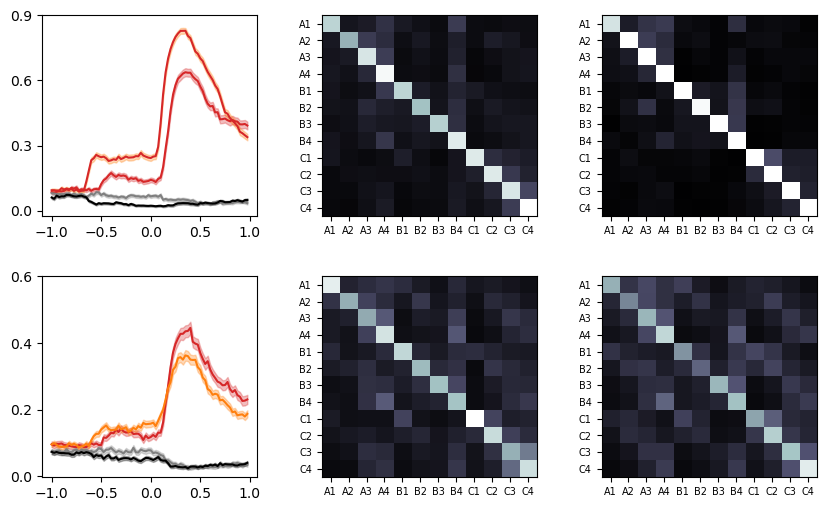

In [12]:
fig, ax = plt.subplots(2, 3, figsize=(10, 6))
fig.subplots_adjust(wspace=0.3, hspace=.3)

# PLOT THE POSTERIOR TRACES
ts_sec = ts/1000
ax[0,0].fill_between(ts_sec, d_ofc_true_mean - d_ofc_true_ci, d_ofc_true_mean + d_ofc_true_ci, color = 'tab:red', alpha = .3)
ax[0,0].plot(ts_sec, d_ofc_true_mean, color = 'tab:red')
ax[0,0].fill_between(ts_sec, d_ofc_counter_mean - d_ofc_counter_ci, d_ofc_counter_mean + d_ofc_counter_ci, color = 'tab:gray', alpha = .3)
ax[0,0].plot(ts_sec, d_ofc_counter_mean, color = 'tab:gray')
ax[0,0].fill_between(ts_sec, k_ofc_true_mean - k_ofc_true_ci, k_ofc_true_mean + k_ofc_true_ci, color = 'tab:orange', alpha = .3)
ax[0,0].plot(ts_sec, k_ofc_true_mean, color = 'tab:red')
ax[0,0].fill_between(ts_sec, k_ofc_counter_mean - k_ofc_counter_ci, k_ofc_counter_mean + k_ofc_counter_ci, color = 'black', alpha = .3)
ax[0,0].plot(ts_sec, k_ofc_counter_mean, color = 'black')
ax[0,0].set_xticks((-1, -.5, 0, .5, 1))
ax[0,0].set_yticks((0, .3, .6, .9))
ax[1,0].fill_between(ts_sec, d_cdn_true_mean - d_cdn_true_ci, d_cdn_true_mean + d_cdn_true_ci, color = 'tab:red', alpha = .3)
ax[1,0].plot(ts_sec, d_cdn_true_mean, color = 'tab:red')
ax[1,0].fill_between(ts_sec, d_cdn_counter_mean - d_cdn_counter_ci, d_cdn_counter_mean + d_cdn_counter_ci, color = 'tab:gray', alpha = .3)
ax[1,0].plot(ts_sec, d_cdn_counter_mean, color = 'tab:gray')
ax[1,0].fill_between(ts_sec, k_cdn_true_mean - k_cdn_true_ci, k_cdn_true_mean + k_cdn_true_ci, color = 'tab:orange', alpha = .3)
ax[1,0].plot(ts_sec, k_cdn_true_mean, color = 'tab:orange')
ax[1,0].fill_between(ts_sec, k_cdn_counter_mean - k_cdn_counter_ci, k_cdn_counter_mean + k_cdn_counter_ci, color = 'black', alpha = .3)
ax[1,0].plot(ts_sec, k_cdn_counter_mean, color = 'black')
ax[1,0].set_xticks((-1, -.5, 0, .5, 1))
ax[1,0].set_yticks((0, .2, .4, .6))

# PLOT THE CONFUSION MATRICES
confusion_labels = [f'{state}{val}' for state in ['A', 'B', 'C'] for val in ['1', '2', '3', '4']]

ax[0,1].imshow(d_ofc_confusion, aspect='auto', vmin=0, vmax=.5, cmap='bone')
im_ofc = ax[0,2].imshow(k_ofc_confusion, aspect='auto', vmin=0, vmax=.5, cmap='bone')
ax[1,1].imshow(d_cdn_confusion, aspect='auto', vmin=0, vmax=.4, cmap='bone')
im_cdn = ax[1,2].imshow(k_cdn_confusion, aspect='auto', vmin=0, vmax=.4, cmap='bone')

# Apply labels to all confusion matrix plots
for ax_cm in [ax[0,1], ax[0,2], ax[1,1], ax[1,2]]:
    ax_cm.set_xticks(range(12))
    ax_cm.set_yticks(range(12))
    ax_cm.set_xticklabels(confusion_labels, fontsize=7)
    ax_cm.set_yticklabels(confusion_labels, fontsize=7)

# Add colorbars to the right-most confusion matrices
# fig.colorbar(im_ofc, ax=ax[0,2], fraction=0.046, pad=0.04)
# fig.colorbar(im_cdn, ax=ax[1,2], fraction=0.046, pad=0.04)

# save the figure
#fig.savefig('matched_decoders_and_confusion_mats_no-CB.svg')